In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv(r"C:\Users\sneha\Downloads\archive (1)\StudentsPerformance.csv")

In [5]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [6]:
df.shape

(1000, 8)

In [7]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [9]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

# Check Negative Values

In [11]:
print((df["math score"] < 0).sum())
print((df["reading score"] < 0).sum())
print((df["writing score"] < 0).sum())

0
0
0


# Verify Data Types

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


# Calculate Subject Averages
Math Average

In [13]:
avg_math = df["math score"].mean()

Reading Average

In [14]:
avg_read = df["reading score"].mean()

Writing Average

In [15]:
avg_write = df["writing score"].mean()

In [16]:
averages = {
    "Math Average": round(avg_math,2),
    "Reading Average": round(avg_read,2),
    "Writing Average": round(avg_write,2)
}

print(averages)

{'Math Average': np.float64(66.09), 'Reading Average': np.float64(69.17), 'Writing Average': np.float64(68.05)}


# Identify Top 5 Students

Create Total Score Column

In [17]:
df["total_score"] = (
    df["math score"] +
    df["reading score"] +
    df["writing score"]
)

Display Top 5 Students

In [18]:
top_students = df.sort_values(
    by="total_score",
    ascending=False
).head(5)

top_students

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total_score
916,male,group E,bachelor's degree,standard,completed,100,100,100,300
962,female,group E,associate's degree,standard,none,100,100,100,300
458,female,group E,bachelor's degree,standard,none,100,100,100,300
114,female,group E,bachelor's degree,standard,completed,99,100,100,299
712,female,group D,some college,standard,none,98,100,99,297


# Generate Visualizations

# 1. Distribution of Math Scores

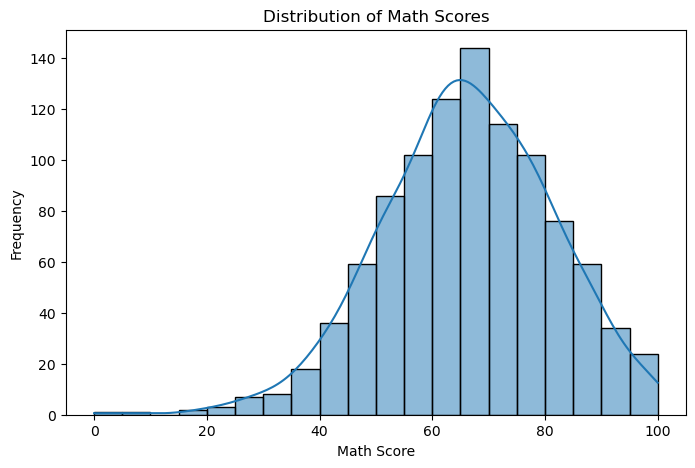

In [19]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["math score"],
    bins=20,
    kde=True
)

plt.title("Distribution of Math Scores")
plt.xlabel("Math Score")
plt.ylabel("Frequency")

plt.show()

# 2. Average Scores by Gender

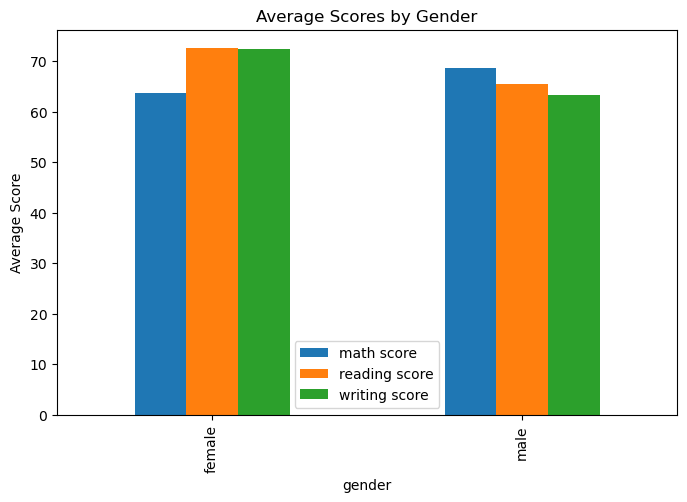

In [20]:
gender_scores = df.groupby("gender")[
    ["math score",
     "reading score",
     "writing score"]
].mean()

gender_scores.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Scores by Gender")
plt.ylabel("Average Score")

plt.show()

# 3. Parental Education vs Student Performance

In [21]:
education_scores = df.groupby(
    "parental level of education"
)[
    "total_score"
].mean().sort_values()

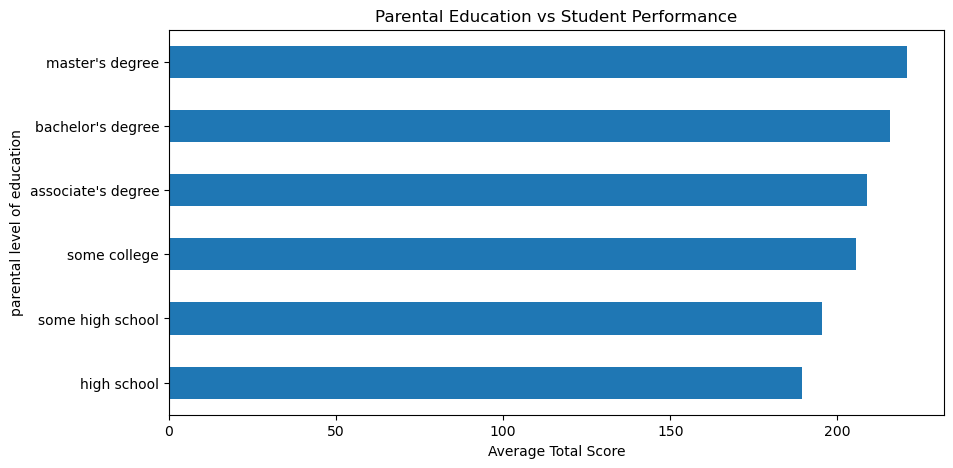

In [22]:
plt.figure(figsize=(10,5))

education_scores.plot(
    kind="barh"
)

plt.title(
    "Parental Education vs Student Performance"
)

plt.xlabel("Average Total Score")

plt.show()

# 4. Race/Ethnicity vs Average Scores

In [23]:
race_scores = df.groupby(
    "race/ethnicity"
)[
    ["math score",
     "reading score",
     "writing score"]
].mean()

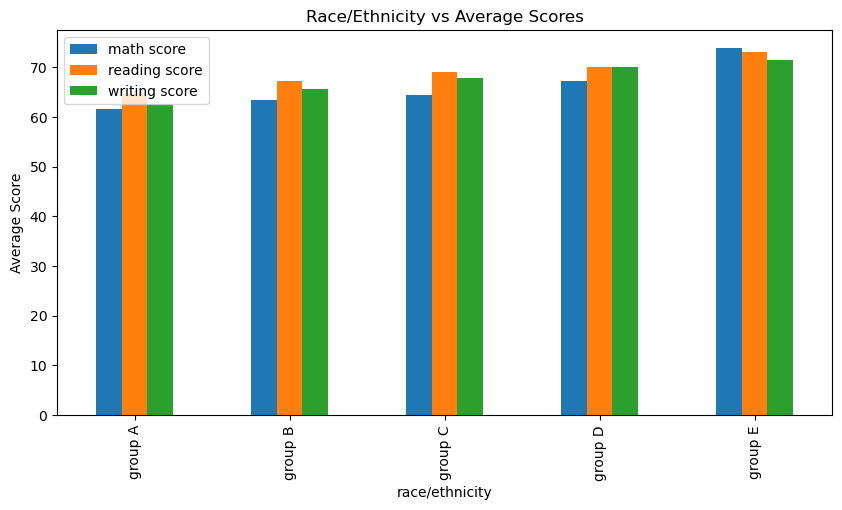

In [24]:
race_scores.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title(
    "Race/Ethnicity vs Average Scores"
)

plt.ylabel("Average Score")

plt.show()

# 5. Reading Score Distribution

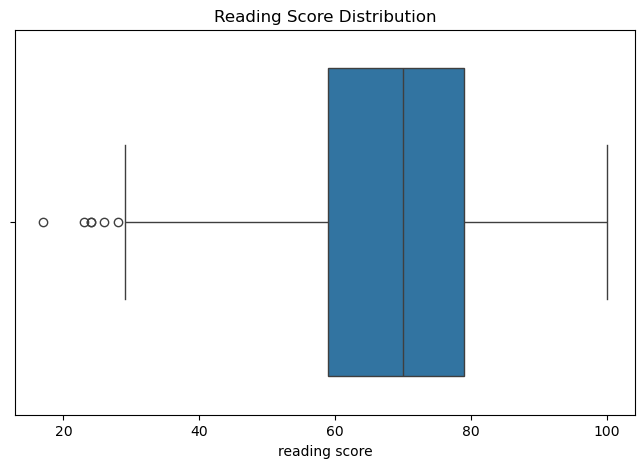

In [25]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["reading score"]
)

plt.title(
    "Reading Score Distribution"
)

plt.show()

# 6. Writing Score Distribution

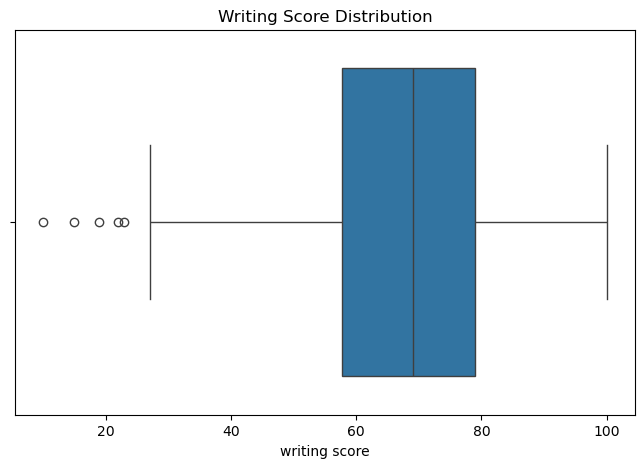

In [27]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["writing score"]
)

plt.title(
    "Writing Score Distribution"
)

plt.show()

# Extract Business Insights



Insights
* Reading scores have the highest average among all subjects.
* Math scores show greater variation compared to reading and writing.
* Female students generally perform better in reading and writing.
* Male students perform slightly better in mathematics.
* Students whose parents have higher education levels tend to score better.
* Group E students achieve the highest average scores.
* Group A students show comparatively lower average performance.
* Students with balanced subject scores rank highest overall.
* Reading and writing scores are strongly correlated.
* Academic performance is influenced by demographic and educational factors.

# 1. Subject-wise Performance Comparison

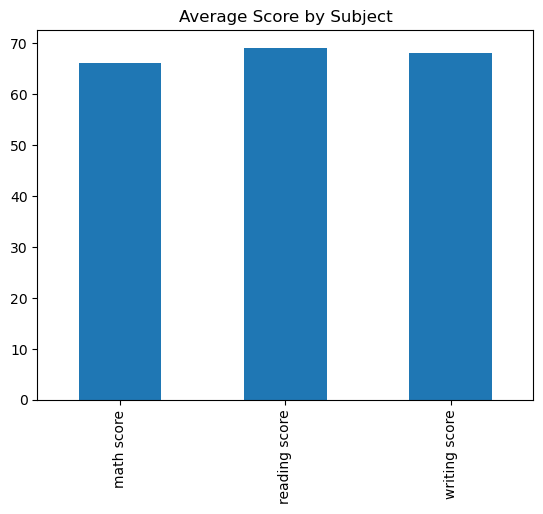

In [29]:
subject_avg = df[["math score","reading score","writing score"]].mean()

subject_avg.plot(kind="bar")
plt.title("Average Score by Subject")
plt.show()

# 2. Correlation Heatmap

Shows relationships between scores.

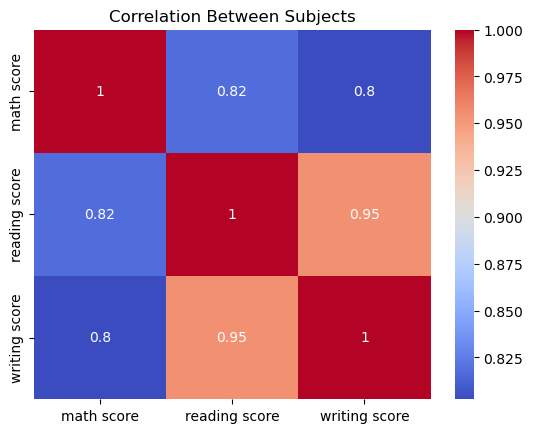

In [30]:
sns.heatmap(
    df[["math score","reading score","writing score"]].corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Between Subjects")
plt.show()

# 3. Test Preparation Course Impact

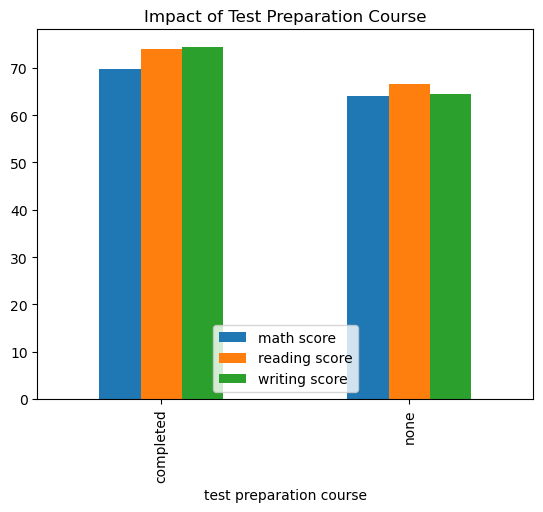

In [31]:
prep = df.groupby(
    "test preparation course"
)[["math score","reading score","writing score"]].mean()

prep.plot(kind="bar")
plt.title("Impact of Test Preparation Course")
plt.show()

# 4. Lunch Type vs Performance

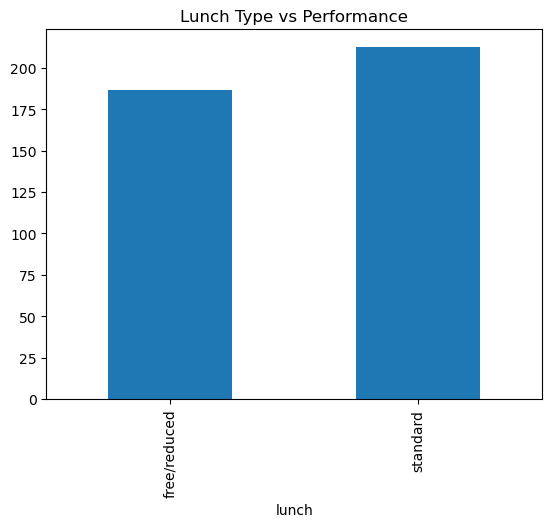

In [32]:
lunch_scores = df.groupby("lunch")["total_score"].mean()

lunch_scores.plot(kind="bar")
plt.title("Lunch Type vs Performance")
plt.show()

# 5. Top 10 Students

Instead of only Top 5.

In [34]:
top10 = df.sort_values(
    by="total_score",
    ascending=False
).head(10)

# 6. Pass/Fail Analysis

Create a new column:

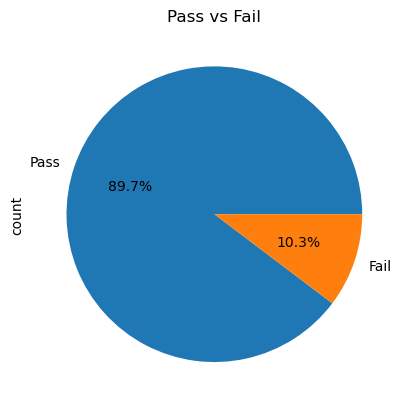

In [35]:
df["Result"] = df["total_score"].apply(
    lambda x: "Pass" if x >= 150 else "Fail"
)

df["Result"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Pass vs Fail")
plt.show()

# 7. Performance Categories

In [36]:
def grade(score):
    if score >= 250:
        return "Excellent"
    elif score >= 200:
        return "Good"
    elif score >= 150:
        return "Average"
    else:
        return "Poor"

df["Performance"] = df["total_score"].apply(grade)

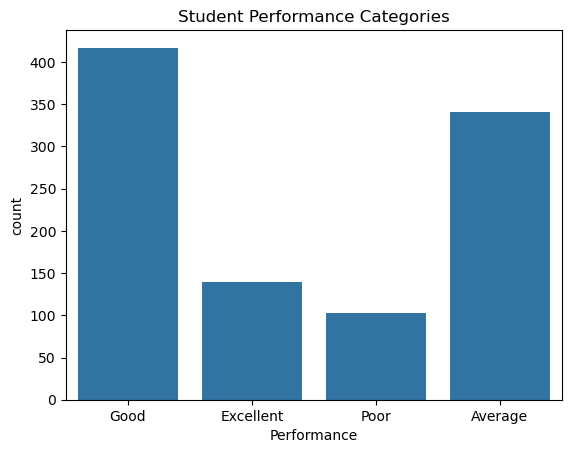

In [37]:
sns.countplot(x="Performance", data=df)
plt.title("Student Performance Categories")
plt.show()

In [38]:
df.to_csv(
    "StudentsPerformance_Cleaned.csv",
    index=False
)